In [1]:
import re
import os
import torch
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from termcolor import colored
import warnings
warnings.filterwarnings('ignore')

import sys
sys.path.append("..")

from util.util_process import load_fasta_seq, load_embeddings, load_fasta_ss8, construct_dataset
from model import Model
from util.util_metric import reg_loss,  evaluate

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def load_model(new_model, path_pretrain_model):
    pretrained_dict = torch.load(path_pretrain_model, map_location=torch.device('cpu'))
    new_model_dict = new_model.state_dict()
    pretrained_dict = {k: v for k, v in pretrained_dict.items() if k in new_model_dict}
    new_model_dict.update(pretrained_dict)
    new_model.load_state_dict(new_model_dict)
    return new_model


def predict(test_iter, path_pretrain_model, sequence_ids, seq_test_dict):
    model = Model(protT5_dim = protT5_dim, max_len = max_len).to(device)
    model = load_model(model, path_pretrain_model)
    model.eval()

    with torch.no_grad():
        test_performance, test_roc_data, test_prc_data, label_real, test_loss, pred_prob, label_pred = evaluate(test_iter, model, reg_loss)

    # Create a DataFrame containing the prediction results, using sequences_id as the sequence ID.
    sequences = [seq_test_dict[i] for i in sequence_ids]
    results_df = pd.DataFrame({
        'sequence_id': sequence_ids,
        'sequence': sequences,
        'real_label': label_real,
        'pred_prob': pred_prob,
        'pred_label': label_pred
    })

    os.makedirs("Predict", exist_ok=True)

    output_file = f"Predict/predict.csv"
    results_df.to_csv(output_file, index=False)
    print(f"The prediction results have been saved to: {output_file}")

    test_results = '\n' + '=' * 45 + colored(' Independent Test Performance', 'red') + '=' * 45 \
                  + '\n[ACC,\t\tAUC,\t\tAUPRC,\t\tSE,\t\tSP,\t\tF1,\t\tPre,\t\tMCC]\n' + \
        '{:.4f},\t\t{:.4f},\t\t{:.4f},\t\t{:.4f},\t\t{:.4f},\t\t{:.4f},\t\t{:.4f},\t\t{:.4f}'.format(
        test_performance[0], test_performance[1], test_performance[2], test_performance[3],test_performance[4], 
        test_performance[5], test_performance[6], test_performance[7]) + '\n' + '=' * 120

    test_roc_data = np.array(test_roc_data, dtype=object)
    test_prc_data = np.array(test_prc_data, dtype=object)

    return test_results, test_roc_data, test_prc_data


def reorder_by_ids(ids, *dicts):
    """Rearrange multiple dictionaries in the order of the specified IDs"""
    return [{k: d[k] for k in ids} for d in dicts]


In [3]:
def plot_roc_curve(FPR, TPR, AUC):
    plt.figure(figsize=(6, 5))
    plt.plot(FPR, TPR, color="#3681AB", label=f'ROC curve(AUROC={AUC:.3f})')

    plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)
    plt.title('ROC Curve on Test Set')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right', fontsize=12)

    plt.tight_layout()
    plt.show()


def plot_pr_curve(recall, precision, AUPRC):
    plt.figure(figsize=(6, 5))
    plt.plot(recall, precision, color="#3681AB", label=f'Model(AUPRC={AUPRC:.3f})')

    plt.plot([0, 1], [1, 0], 'k--', alpha=0.5)
    plt.title('PR Curve on Test Set')
    plt.xlabel('Recall Rate')
    plt.ylabel('Precision Rate')
    plt.legend(loc='lower left', fontsize=12)

    plt.tight_layout()
    plt.show()

ProtT5 feature dimension: 1024
The prediction results have been saved to: Predict/predict.csv

============================================= Independent Test Performance=============================================
[ACC,		AUC,		AUPRC,		SE,		SP,		F1,		Pre,		MCC]
0.9482,		0.9796,		0.9758,		0.9505,		0.9459,		0.9483,		0.9462,		0.8964


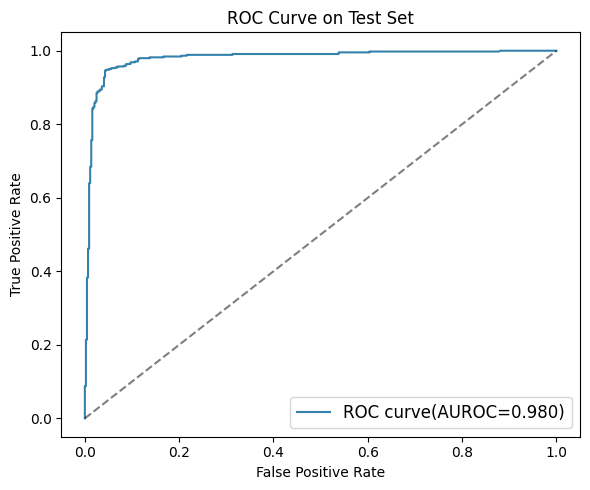

In [4]:
max_len = 100
seq_folder = "datasets/NeuroP_data"
protT5_folder = 'datasets/NeuroP_feature/ProtT5'
ss_folder = 'datasets/NeuroP_feature/ss8'    
    
seq_test_dict, _ = load_fasta_seq(seq_folder, is_training=False)
protT5_test_dict, labels_test_dict = load_embeddings(protT5_folder, max_length=max_len, is_training=False)
ss_test_dict, _ , mask_test_dict = load_fasta_ss8(ss_folder, max_length=max_len, is_training=False)

first_key = list(protT5_test_dict.keys())[0]
protT5_dim = protT5_test_dict[first_key].shape[1]
print(f"ProtT5 feature dimension: {protT5_dim}")

# ID sorting: Positive first, then Negative
all_ids = list(labels_test_dict.keys())

pos_ids = sorted([i for i in all_ids if i.startswith("Positive")], key=lambda x: int(re.findall(r"\d+", x)[0]))
neg_ids = sorted([i for i in all_ids if i.startswith("Negative")], key=lambda x: int(re.findall(r"\d+", x)[0]))
sequence_ids = pos_ids + neg_ids

# Unified dictionary order
protT5_test_dict, ss_test_dict, mask_test_dict, labels_test_dict, seq_test_dict = \
        reorder_by_ids(sequence_ids,protT5_test_dict, ss_test_dict,mask_test_dict,labels_test_dict,seq_test_dict )

test_iter = construct_dataset(protT5_test_dict, ss_test_dict, mask_test_dict, labels_test_dict, train=False)

path_pretrain_model = 'NeuroPred_PSCG_Model.pt'
test_result, test_roc_data, test_prc_data = predict(test_iter, path_pretrain_model, sequence_ids, seq_test_dict)
print(test_result)

# Draw the ROC curve
FPR, TPR, AUC = test_roc_data
plot_roc_curve(FPR, TPR, AUC)